## Softmax Regression

In [14]:
import numpy as np

class MySoftmaxRegression:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr=lr
        self.epochs=epochs
        
    # Softmax
    def softmax(self, z):
        exp_z=np.exp(z-np.max(z, axis=1, keepdims=True))
        return exp_z/np.sum(exp_z, axis=1, keepdims=True)
    
    # One-hot encoding
    def one_hot(self, y, num_classes):
        one_hot=np.zeros((len(y), num_classes))
        one_hot[np.arange(len(y)), y]=1
        return one_hot
    
    # Training
    def fit(self, X, y):
        n_samples, n_features=X.shape
        self.num_classes=len(np.unique(y))
        
        # Initialize weights
        self.W=np.zeros((n_features, self.num_classes))
        self.b=np.zeros((1, self.num_classes))
        
        Y=self.one_hot(y, self.num_classes)
        
        for epoch in range(self.epochs):
            z=np.dot(X, self.W)+self.b
            probs=self.softmax(z)
            
            # Loss
            loss=-np.mean(np.sum(Y*np.log(probs+1e-9), axis=1))
            
            # Gradient
            dW=(1/n_samples)*np.dot(X.T, (probs-Y))
            db=(1/n_samples)*np.sum(probs-Y, axis=0, keepdims=True)
            
            # Update
            self.W-=self.lr*dW
            self.b-=self.lr*db
            
            if epoch%100==0:
                print(f"Epoch {epoch}, Loss:{loss:.4f}")
                
    
    # Predict Probabilities
    def predict_proba(self, X):
        z=np.dot(X, self.W)+self.b
        return self.softmax(z)
    
    # Predict class
    def predict(self, X):
        probs=self.predict_proba(X)
        return np.argmax(probs, axis=1)
    
    def score(self, X, y):
        preds=self.predict(X)
        return np.mean(preds==y)

## Binary Logistic Regression

In [15]:
class MyLogisticRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr=lr
        self.epochs=epochs
        
    def sigmoid(self, z):
        return 1/(1+np.exp(-z))
    
    
    def fit(self, X, y):
        n_samples, n_features=X.shape
        
        self.W=np.zeros(n_features)
        self.b=0
        
        for epoch in range(self.epochs):
            z=np.dot(X, self.W)+self.b
            y_pred=self.sigmoid(z)
            
            # gradients
            dW=(1/n_samples)*np.dot(X.T, (y_pred-y))
            db=(1/n_samples)*np.sum(y_pred-y)
            
            # Update
            self.W-=self.lr*dW
            self.b-=self.lr*db
    
    
    def predict_proba(self, X):
        z=np.dot(X, self.W)+self.b
        return self.sigmoid(z)
    
    def predict(self, X):
        return (self.predict_proba(X)>=0.5).astype(int)
    

## One-vs-Rest

In [16]:
class MyOneVsRest:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr=lr
        self.epochs=epochs
        self.models=[]
        self.classes=None
        
    def fit(self,X, y):
        self.classes=np.unique(y)
        self.models=[]
        
        for c in self.classes:
            print(f"Training class {c} vs Rest")
            
            y_binary=(y==c).astype(int)
            
            model=MyLogisticRegression(self.lr, self.epochs)
            model.fit(X, y_binary)
            
            self.models.append(model)
            
    
    def predict_proba(self, X):
        probs=[]
        
        for model in self.models:
            probs.append(model.predict_proba(X))
            
        return np.array(probs).T
    
    def predict(self, X):
        probs=self.predict_proba(X)
        return np.argmax(probs, axis=1)
    
    def score(self, X, y):
        preds=self.predict(X)
        return np.mean(preds==y)

## One-vs-One 

In [17]:
from itertools import combinations

class MyOneVsOne:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr=lr
        self.epochs=epochs
        self.models=[]
        self.pairs=[]
        
        
    def fit(self, X, y):
        self.classes=np.unique(y)
        self.models=[]
        self.pairs=[]
        
        for (c1, c2) in combinations(self.classes, 2):
            print(f"Training {c1} vs {c2}")
            
            # select only these two classes
            idx=(y==c1)|(y==c2)
            X_pair=X[idx]
            y_pair=y[idx]
            
            # convert labels to binary
            y_binary=(y_pair==c1).astype(int)
            
            model=MyLogisticRegression(self.lr, self.epochs)
            model.fit(X_pair, y_binary)
            
            self.models.append(model)
            self.pairs.append((c1, c2))
            
            
    def predict(self, X):
        votes=np.zeros((X.shape[0], len(self.classes)))
        
        for model , (c1, c2) in zip(self.models, self.pairs):
            preds=model.predict(X)
            
            for i in range(len(preds)):
                if preds[i]==1:
                    votes[i, c1]+=1
                else:
                    votes[i, c2]+=1
                    
        return np.argmax(votes, axis=1)
    
    def score(self, X, y):
        preds=self.predict(X)
        return np.mean(preds==y)

## Example Usage


In [18]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load dataset
digits=load_digits()

X=digits.data
y=digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)

# Train/Test Split
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


X shape: (1797, 64)
y shape: (1797,)


In [19]:
################## OvR Model
ovr=MyOneVsRest(lr=0.1, epochs=1000)
ovr.fit(X_train, y_train)

# Predict
ovr_pred=ovr.predict(X_test)
print("OvR Accuracy:")
print(np.mean(ovr_pred==y_test))

# Example
sample = X_test[0:1]

print("Predicted:", ovr.predict(sample))
print("True:", y_test[0])

Training class 0 vs Rest
Training class 1 vs Rest
Training class 2 vs Rest
Training class 3 vs Rest
Training class 4 vs Rest
Training class 5 vs Rest
Training class 6 vs Rest
Training class 7 vs Rest
Training class 8 vs Rest
Training class 9 vs Rest
OvR Accuracy:
0.9611111111111111
Predicted: [6]
True: 6


In [20]:
#### Softmax Model
softmax = MySoftmaxRegression(
    lr=0.1,
    epochs=1000
)

softmax.fit(X_train, y_train)

softmax_pred = softmax.predict(X_test)

print("Softmax Accuracy:")
print(np.mean(softmax_pred == y_test))

Epoch 0, Loss:2.3026
Epoch 100, Loss:0.2934
Epoch 200, Loss:0.1998
Epoch 300, Loss:0.1607
Epoch 400, Loss:0.1376
Epoch 500, Loss:0.1220
Epoch 600, Loss:0.1104
Epoch 700, Loss:0.1013
Epoch 800, Loss:0.0940
Epoch 900, Loss:0.0880
Softmax Accuracy:
0.9694444444444444


In [21]:
######## OvO
ovo = MyOneVsOne(
    lr=0.1,
    epochs=1000
)

ovo.fit(X_train, y_train)

# Predict
ovo_pred=ovo.predict(X_test)

print("OvO Accuracy:")
print(np.mean(ovo_pred == y_test))


Training 0 vs 1
Training 0 vs 2
Training 0 vs 3
Training 0 vs 4
Training 0 vs 5
Training 0 vs 6
Training 0 vs 7
Training 0 vs 8
Training 0 vs 9
Training 1 vs 2
Training 1 vs 3
Training 1 vs 4
Training 1 vs 5
Training 1 vs 6
Training 1 vs 7
Training 1 vs 8
Training 1 vs 9
Training 2 vs 3
Training 2 vs 4
Training 2 vs 5
Training 2 vs 6
Training 2 vs 7
Training 2 vs 8
Training 2 vs 9
Training 3 vs 4
Training 3 vs 5
Training 3 vs 6
Training 3 vs 7
Training 3 vs 8
Training 3 vs 9
Training 4 vs 5
Training 4 vs 6
Training 4 vs 7
Training 4 vs 8
Training 4 vs 9
Training 5 vs 6
Training 5 vs 7
Training 5 vs 8
Training 5 vs 9
Training 6 vs 7
Training 6 vs 8
Training 6 vs 9
Training 7 vs 8
Training 7 vs 9
Training 8 vs 9
OvO Accuracy:
0.9833333333333333


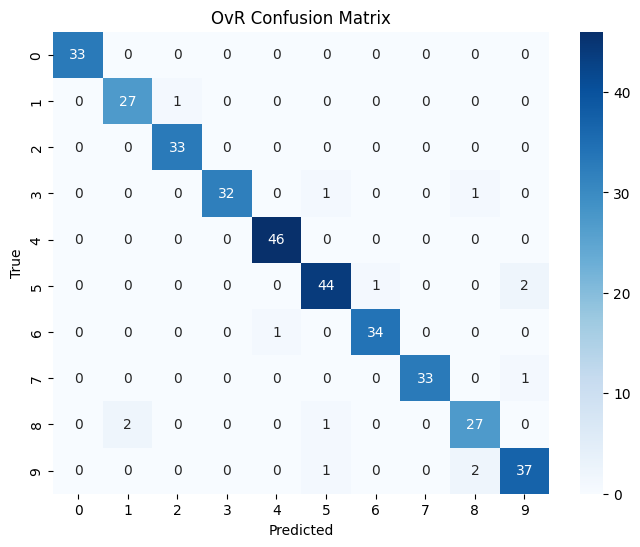

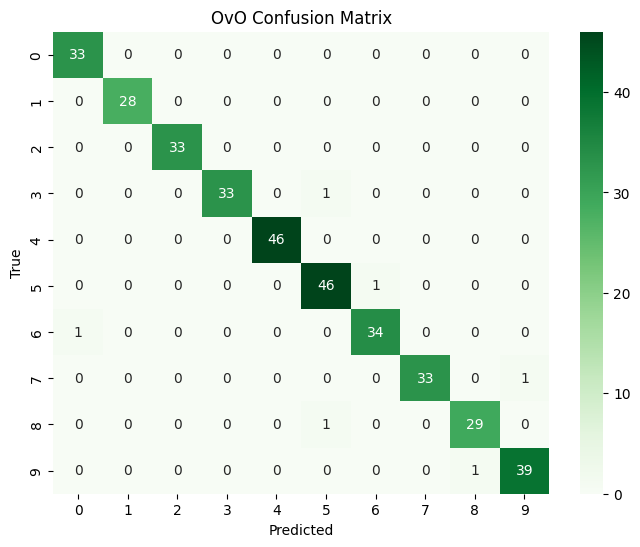

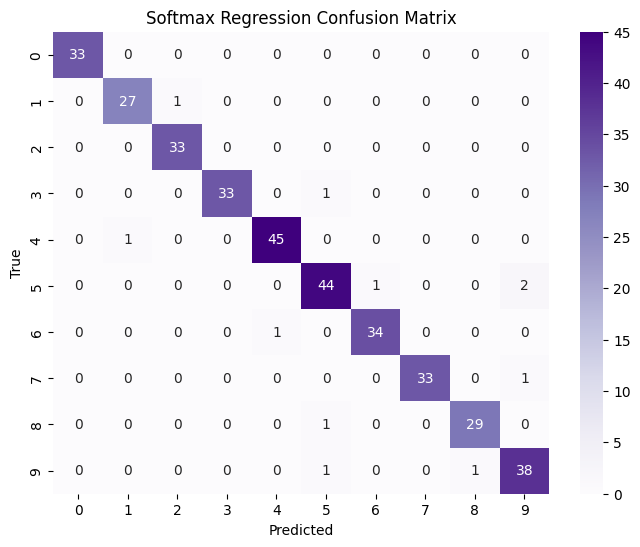

In [22]:
##### Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# OvR confusion matrix
cm_ovr = confusion_matrix(y_test, ovr_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm_ovr, annot=True, fmt='d', cmap='Blues')

plt.title("OvR Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()


# OvO confusion matrix
cm_ovo = confusion_matrix(y_test, ovo_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm_ovo, annot=True, fmt='d', cmap='Greens')

plt.title("OvO Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()


# Confusion Matrix for Softmax
cm_softmax = confusion_matrix(y_test, softmax_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_softmax,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Softmax Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()


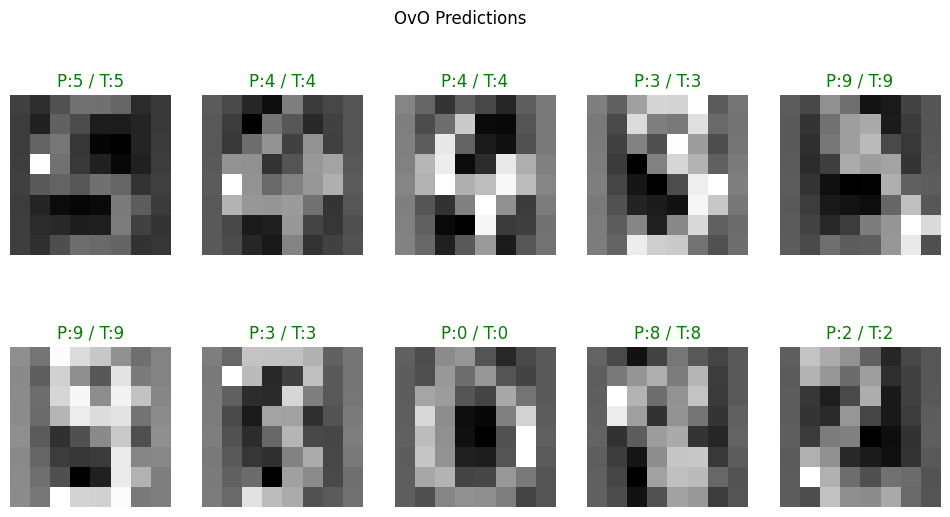

In [23]:
## Visualize Predictions
import random

indices = random.sample(range(len(X_test)), 10)

plt.figure(figsize=(12,6))

for i, idx in enumerate(indices):

    plt.subplot(2,5,i+1)

    image = X_test[idx].reshape(8,8)

    pred = ovo_pred[idx]
    true = y_test[idx]

    color = "green" if pred == true else "red"

    plt.imshow(image, cmap='gray')

    plt.title(f"P:{pred} / T:{true}", color=color)

    ax = plt.gca()

    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

    plt.axis('off')

plt.suptitle("OvO Predictions")
plt.show()